# Modelagem
Este notebook tem como objetivo:
- Testar diferentes modelos na base que foi processada em feature_engineering.ipynb
- Definir métricas de performance
- Verificar a performance da baseline
- Selecionar um algoritmo de predição
- Otimizar hiperparâmetros do modelo selecionado
- Propor estratégia de definição de metas
- Propor estratégia de produtização

# Setup

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import xgboost as xgb
from xgboost import XGBRegressor
import lightgbm as lgb
from lightgbm import LGBMRegressor
import optuna
from optuna.samplers import TPESampler
from scipy.optimize import brentq

pd.set_option('display.max_columns', None)

### Leitura dos dados

In [2]:
df_model = pd.read_csv('Data/processed/base_modelagem_features.csv')
df_model['data'] = pd.to_datetime(df_model['data'])
df_model = df_model.sort_values(by=['codigo_filial', 'data'])
df_model.head()

,codigo_filial,data,faturamento,quantidade,quantidade_tickets,faturamento_medio_ticket,meta_n_med,faixa_vida,tipo_estabelecimento,delivery,metragem_area_venda,panvel_clinic,estacionamento,atendimento_24_horas,local_tipo_mm7,local_tipo_mm15,local_tipo_mm30,tipo_estabelecimento_copy_BAIRRO,tipo_estabelecimento_copy_CENTRO,tipo_estabelecimento_copy_MALL,tipo_estabelecimento_copy_SHOPPING,is_weekend,cluster_comportamento,fat_lag_7,fat_lag_8,fat_mm_2,fat_mm_3,fat_mm_4,fat_mm_5,fat_mm_7,dia_do_mes,dia_da_semana,semana_do_mes,is_pagamento,sin_dia_semana,cos_dia_semana,sin_dia_mes,cos_dia_mes,is_feriado,vespera_feriado,is_semana_feriado,qtd_lag_7,qtd_mm_7,preco_medio_mm_7,preco_medio_mm_30,tickets_lag_7,tickets_mm_7,tickets_mm_30,vies_meta_mm_7,meta_n_med_tgt,target
0,1500,2025-01-01,18077.83704,828.0,138.0,130.998819,12732.76,2,CENTRO,0,309.0388,0,0,0,NaN,NaN,NaN,False,True,False,False,0,4,NaN,NaN,18077.83704,18077.83704,18077.837040,18077.837040,18077.837040,1,2,1,0,0.974928,-0.222521,0.201299,0.979530,1,0,1,NaN,828.0,21.833137,21.833137,NaN,138.000000,138.000000,1.419789,12732.76,18077.83704
1,1500,2025-01-02,18077.83704,828.0,138.0,130.998819,12732.76,2,CENTRO,0,309.0388,0,0,0,19189.083578,19189.083578,19189.083578,False,True,False,False,0,4,NaN,NaN,18077.83704,18077.83704,18077.837040,18077.837040,18077.837040,2,3,1,0,0.433884,-0.900969,0.394356,0.918958,0,0,0,NaN,828.0,21.833137,21.833137,NaN,138.000000,138.000000,1.419789,12732.76,29631.50298
2,1500,2025-01-03,29631.50298,1107.0,188.0,157.614378,12732.76,2,CENTRO,0,309.0388,0,0,0,20767.440004,20767.440004,20767.440004,False,True,False,False,0,4,NaN,NaN,23854.67001,21929.05902,21929.059020,21929.059020,21929.059020,3,4,1,0,-0.433884,-0.900969,0.571268,0.820763,0,0,0,NaN,921.0,23.477888,23.477888,NaN,154.666667,154.666667,1.722255,12732.76,14137.64100
3,1500,2025-01-04,14137.64100,597.0,98.0,144.261643,12732.76,2,CENTRO,0,309.0388,0,0,0,24959.255010,24959.255010,24959.255010,False,True,False,False,1,4,NaN,NaN,21884.57199,20615.66034,19981.204515,19981.204515,19981.204515,4,5,1,0,-0.974928,-0.222521,0.724793,0.688967,0,0,0,NaN,840.0,23.528701,23.528701,NaN,140.500000,140.500000,1.569275,12732.76,18077.83704
4,1500,2025-01-05,18077.83704,828.0,138.0,130.998819,12732.76,2,CENTRO,0,309.0388,0,0,0,24043.300802,24043.300802,24043.300802,False,True,False,False,1,4,NaN,NaN,16107.73902,20615.66034,19981.204515,19600.531020,19600.531020,5,6,1,1,-0.781831,0.623490,0.848644,0.528964,0,0,0,NaN,837.6,23.189588,23.189588,NaN,140.000000,140.000000,1.539378,22143.91,21558.72465


In [3]:
#df_1857 = df_model[df_model['codigo_filial'] == 1857].reset_index(drop=True).copy()
#df_1521 = df_model[df_model['codigo_filial'] == 1521].reset_index(drop=True).copy()
df_model = df_model[~df_model['codigo_filial'].isin([1521])].reset_index(drop=True).copy()

### Funções

In [4]:
def calcular_metricas_vendas(y_true, y_pred):
    # Erro médio em Reais
    mae = mean_absolute_error(y_true, y_pred)
    
    # Erro quadrático (penaliza grandes desvios)
    rmse = root_mean_squared_error(y_true, y_pred)
    
    # WAPE: Erro percentual ponderado
    # Evita que filiais pequenas distorçam a média
    wape = np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)
    
    return {
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'WAPE': round(wape, 4)
    }


def avaliar_performance_detalhada(df, col_target, col_pred):
    metricas_globais = calcular_metricas_vendas(df[col_target], df[col_pred])
    
    metricas_filiais = df.groupby('codigo_filial').apply(
        lambda x: pd.Series(calcular_metricas_vendas(x[col_target], x[col_pred]))
    ).reset_index()
    
    metricas_clusters = df.groupby('cluster_comportamento').apply(
        lambda x: pd.Series(calcular_metricas_vendas(x[col_target], x[col_pred]))
    ).reset_index()
    
    # Exige que a coluna original tipo_estabelecimento ainda exista no df
    metricas_tipo = df.groupby('tipo_estabelecimento').apply(
        lambda x: pd.Series(calcular_metricas_vendas(x[col_target], x[col_pred]))
    ).reset_index()
    
    return metricas_globais, metricas_filiais, metricas_clusters, metricas_tipo


# Separa treino, teste e validação se solicitado
def preparar_treino_teste(df, features, apenas_teste=True):
    # Define o periodo de teste como os ultimos dois meses do ano
    mask_teste = df['data'].dt.month.isin([11, 12])
    
    if apenas_teste:
        # Treinamento realizado com o historico disponivel de Janeiro a Outubro
        train = df[~mask_teste].copy()
        test = df[mask_teste].copy()
        
        X_train = train[features]
        y_train_log = np.log1p(train['target'])
        y_train = train['target']
        X_test = test[features]
        y_test = test['target']
        
        # Retorna None nos campos de validacao para manter consistencia na assinatura
        return X_train, None, X_test, y_train_log, y_train, None, y_test, test

    # Reserva os meses nove e dez para validacao e os anteriores para treino
    mask_val = df['data'].dt.month.isin([10])
    train = df[df['data'].dt.month < 10].copy()
    val = df[mask_val].copy()
    test = df[mask_teste].copy()
    
    X_train = train[features]
    y_train_log = np.log1p(train['target'])
    y_train = train['target']
    X_val = val[features]
    y_val = val['target']
    X_test = test[features]
    y_test = test['target']
    
    return X_train, X_val, X_test, y_train_log, y_train, y_val, y_test, test


# Avaliacao para modelos lineares com reversao de escala
def treinar_e_avaliar_reg(modelo_pipeline, X_train, y_train_log, X_test, df_teste):
    modelo_pipeline.fit(X_train, y_train_log)
    
    df_resultado = df_teste.copy()
    df_resultado['predicao'] = np.expm1(modelo_pipeline.predict(X_test))
    
    res_global, res_filial, res_clusters, res_tipo = avaliar_performance_detalhada(
        df_resultado, 'target', 'predicao'
    )
    
    return res_global, res_clusters, res_tipo, df_resultado


# Avaliacao nativa para arvores e boosting na escala original
def treinar_e_avaliar_arvore(modelo_pipeline, X_train, y_train, X_test, df_teste):
    modelo_pipeline.fit(X_train, y_train)
    
    df_resultado = df_teste.copy()
    df_resultado['predicao'] = modelo_pipeline.predict(X_test)
    
    res_global, res_filial, res_clusters, res_tipo = avaliar_performance_detalhada(
        df_resultado, 'target', 'predicao'
    )
    
    return res_global, res_clusters, res_tipo, df_resultado

In [5]:
def plotar_analise_global(df_resultado):
    # Agrupamento temporal para o grafico de linha
    df_temp = df_resultado.groupby('data')[['target', 'predicao']].mean().reset_index()
    
    fig = make_subplots(
        rows=1, cols=2, 
        subplot_titles=("Aderência Temporal Rede", "Real vs Predito (Por Filial/Dia)")
    )

    # Grafico 1: Serie temporal agregada para ver sazonalidade macro
    fig.add_trace(go.Scatter(x=df_temp['data'], y=df_temp['target'], name='Real'), row=1, col=1)
    fig.add_trace(go.Scatter(x=df_temp['data'], y=df_temp['predicao'], name='Predito'), row=1, col=1)

    # Grafico 2: Scatter plot para validar erro em diferentes escalas
    fig.add_trace(go.Scatter(
        x=df_resultado['target'], 
        y=df_resultado['predicao'], 
        mode='markers',
        opacity=0.5,
        marker=dict(size=4, color='teal'),
        name='Filial/Dia'
    ), row=1, col=2)

    # Adicionando linha de referencia 45 graus (o ideal e os pontos estarem nela)
    max_val = max(df_resultado['target'].max(), df_resultado['predicao'].max())
    fig.add_shape(
        type="line", x0=0, y0=0, x1=max_val, y1=max_val,
        line=dict(color="Red", dash="dash"), row=1, col=2
    )

    fig.update_layout(height=500, template='plotly_white', showlegend=False)
    fig.show()

# Testes
Métricas selecionadas:
- MAE: O dinheiro em sua escala mais pura.
- RMSE: Pra esse caso, diz o quanto o modelo errou nos picos que as filiais apresentam normalmente.
- WAPE: O MAE pode entregar R$500, mas é preciso relativizar com o valor real usando porcentagem.
    - Ao contrario do MAPE, o WAPE vai diferenciar um erro de 5% de uma loja grande pro erro de 25% de uma loja pequena. (O primeiro caso é pior)

In [6]:
FEATURES_NUM = ['faturamento','quantidade','quantidade_tickets','faturamento_medio_ticket','meta_n_med','metragem_area_venda','local_tipo_mm7',
                'local_tipo_mm15', 'local_tipo_mm30','fat_lag_7','fat_lag_8', 'fat_mm_7', 'meta_n_med_tgt',
                'semana_do_mes', 'sin_dia_semana','cos_dia_semana','sin_dia_mes','cos_dia_mes',
                'qtd_lag_7','qtd_mm_7','preco_medio_mm_7','preco_medio_mm_30','tickets_lag_7','tickets_mm_7','tickets_mm_30','vies_meta_mm_7']

FEATURES_CAT = ['faixa_vida','cluster_comportamento']

FEATURES_BOOL = ['delivery','panvel_clinic','estacionamento','atendimento_24_horas', 'tipo_estabelecimento_copy_BAIRRO','tipo_estabelecimento_copy_CENTRO','tipo_estabelecimento_copy_MALL',
                 'tipo_estabelecimento_copy_SHOPPING', 'is_weekend', 'is_pagamento', 'is_feriado', 'vespera_feriado', 'is_semana_feriado']

ID_COLS = ['codigo_filial', 'data']

FEATURES_COL = FEATURES_NUM + FEATURES_CAT + FEATURES_BOOL

In [7]:
features_input = FEATURES_NUM + FEATURES_CAT + FEATURES_BOOL
df_clean = df_model.dropna(subset=features_input + ['target']).sort_values('data')
X_train, _, X_test, y_train_log, y_train, _, y_test, test_df = preparar_treino_teste(df_clean, features_input)

## Multicolinearidade

In [8]:
mask_teste = df_clean['data'].dt.month.isin([10, 11, 12])
df_coll = df_clean[~mask_teste].copy()

### Pearson global

In [9]:
# Calculando a matriz de correlação completa (incluindo target)
corr_matrix = df_coll[FEATURES_NUM + ['target']].corr().abs()

# Separando a correlação apenas com o target
target_corr = corr_matrix['target'].drop('target')

# Pegando a matriz triangular superior das features (para não repetir pares)
upper = corr_matrix.drop('target', axis=0).drop('target', axis=1).where(
    np.triu(np.ones(corr_matrix.shape[0]-1), k=1).astype(bool)
)

# Lógica de seleção automática
to_drop_auto = set()

for column in upper.columns:
    # Identifica colunas com correlação > 0.90 com a coluna atual
    redundant_cols = upper.index[upper[column] > 0.90].tolist()
    
    for redundant in redundant_cols:
        # Compara a correlação de ambas com o target
        if target_corr[column] < target_corr[redundant]:
            to_drop_auto.add(column)
        else:
            to_drop_auto.add(redundant)

print(f"Colunas sugeridas para descarte (n={len(to_drop_auto)}):")
print(list(to_drop_auto))

#COLS_TO_DROP = list(to_drop_auto)

Colunas sugeridas para descarte (n=11):
['qtd_lag_7', 'tickets_lag_7', 'tickets_mm_7', 'preco_medio_mm_7', 'fat_lag_7', 'local_tipo_mm15', 'quantidade_tickets', 'quantidade', 'local_tipo_mm30', 'qtd_mm_7', 'tickets_mm_30']


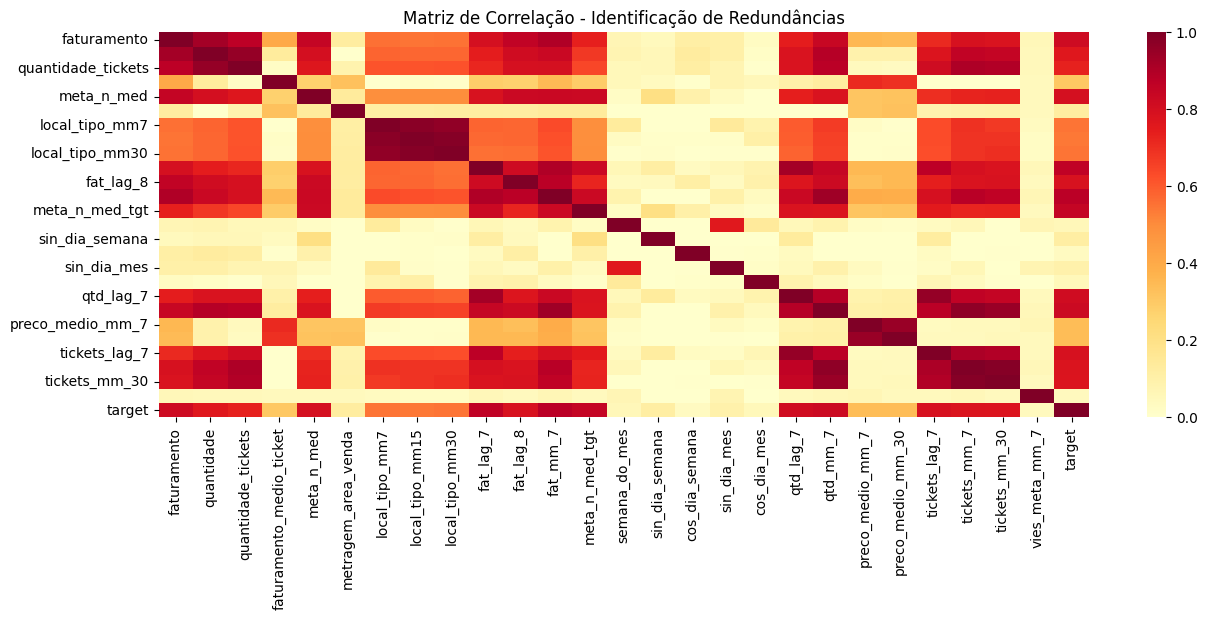

In [10]:
# Plotando o Heatmap para visualização
plt.figure(figsize=(15, 5))
sns.heatmap(corr_matrix, annot=False, cmap='YlOrRd')
plt.title("Matriz de Correlação - Identificação de Redundâncias")
plt.show()

### Pearson por filial

In [11]:
# Define o limite para identificar variáveis redundantes
CORR_THRESHOLD = 0.90

# Inicializa lista para armazenar as matrizes de correlação de cada filial
corr_matrices = []

# Itera por cada filial para capturar o comportamento específico da série temporal
for filial in df_coll['codigo_filial'].unique():
    # Filtra os dados da filial e calcula a correlação absoluta
    df_filial = df_coll[df_coll['codigo_filial'] == filial][FEATURES_NUM + ['target']]
    corr_filial = df_filial.corr().abs()
    
    # Adiciona à lista apenas se a matriz não contiver apenas valores nulos
    if not corr_filial.isnull().all().all():
        corr_matrices.append(corr_filial)

# Consolida a média das correlações para obter um padrão global estável
mean_corr_matrix = pd.concat(corr_matrices).groupby(level=0).mean()

# Extrai a força da relação de cada variável com o alvo a partir da média
target_corr = mean_corr_matrix['target'].drop('target')

# Prepara a matriz triangular superior para análise de pares sem repetição
feat_matrix = mean_corr_matrix.drop('target', axis=0).drop('target', axis=1)
upper = feat_matrix.where(np.triu(np.ones(feat_matrix.shape), k=1).astype(bool))

# Aplica a lógica de descarte automático baseada em redundância e poder preditivo
to_drop_auto = set()

for column in upper.columns:
    # Identifica variáveis que apresentam correlação média superior ao limite definido
    redundant_cols = upper.index[upper[column] > CORR_THRESHOLD].tolist()
    
    for redundant in redundant_cols:
        # Compara a correlação média com o alvo para decidir qual variável preservar
        # A variável com menor vínculo estatístico com o target é marcada para descarte
        if target_corr[column] < target_corr[redundant]:
            to_drop_auto.add(column)
        else:
            to_drop_auto.add(redundant)

# Converte o conjunto de colunas para lista para facilitar o uso no pipeline
COLS_TO_DROP = list(to_drop_auto)

print(f"Colunas sugeridas para descarte via média por filial (n={len(COLS_TO_DROP)}):")
print(COLS_TO_DROP)

Colunas sugeridas para descarte via média por filial (n=11):
['qtd_lag_7', 'preco_medio_mm_30', 'preco_medio_mm_7', 'cos_dia_semana', 'cos_dia_mes', 'fat_lag_7', 'fat_lag_8', 'fat_mm_7', 'meta_n_med_tgt', 'qtd_mm_7', 'tickets_mm_30']


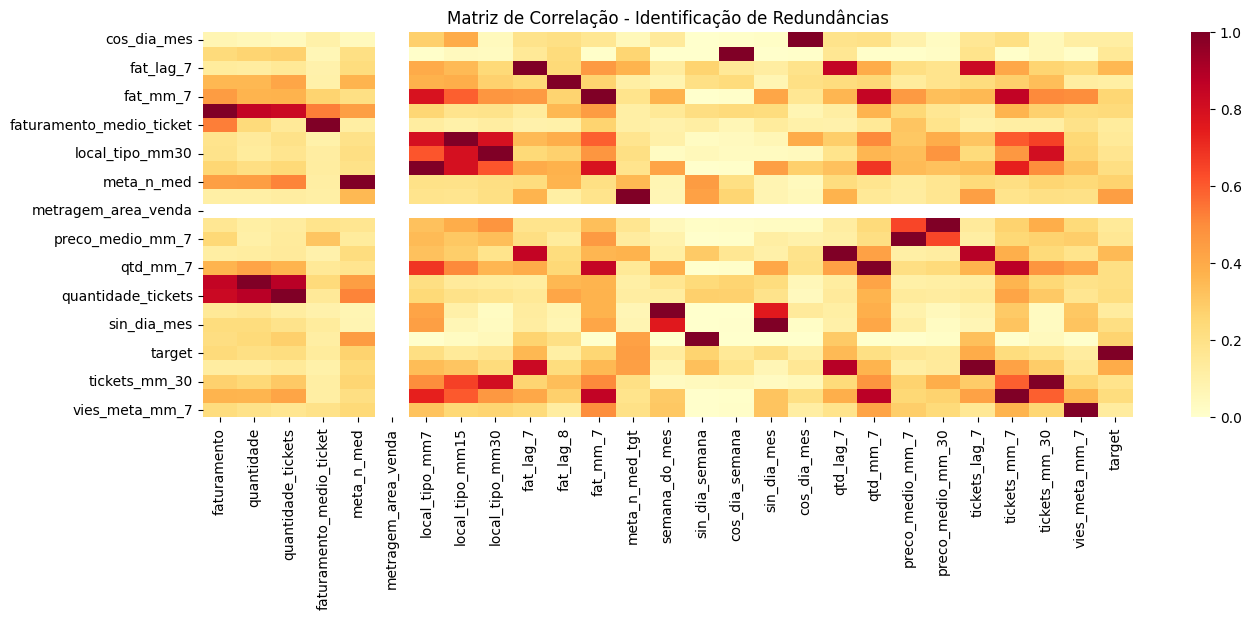

In [12]:
# Plotando o Heatmap para visualização
plt.figure(figsize=(15, 5))
sns.heatmap(mean_corr_matrix, annot=False, cmap='YlOrRd')
plt.title("Matriz de Correlação - Identificação de Redundâncias")
plt.show()

### VIF

In [13]:
# Remove colunas estáticas para o VIF não explodir
features_vif_temporal = [f for f in FEATURES_NUM if f not in ['metragem_area_venda']]

vif_results = []

for filial in df_coll['codigo_filial'].unique():
    df_filial = df_coll[df_coll['codigo_filial'] == filial][features_vif_temporal].copy()
    
    # Preencher NaNs com 0
    df_filial = df_filial.fillna(0)
    
    # intercepto
    X_vif = add_constant(df_filial)
    
    try:
        # Calculamos o VIF para cada feature-filial
        vifs = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
        vif_results.append(vifs)
    except:
        continue

# Médias
df_vif_medio = pd.DataFrame(vif_results, columns=X_vif.columns)
vif_final = df_vif_medio.mean().sort_values(ascending=False).to_frame(name='VIF_Medio')

print("Ranking de Redundância Real (Média por Filial):")
print(vif_final)

c:\Users\User\Documents\.dev\Cases\Data Scientist Case Panvel\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\Users\User\Documents\.dev\Cases\Data Scientist Case Panvel\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\Users\User\Documents\.dev\Cases\Data Scientist Case Panvel\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\Users\User\Documents\.dev\Cases\Data Scientist Case Panvel\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\Users\User\Documents\.dev\Cases\Data Scientist Case Panvel\.venv\Lib\site-packages\statsmodels\stats\outl

Ranking de Redundância Real (Média por Filial):
                             VIF_Medio
faturamento                        inf
local_tipo_mm7                     inf
fat_mm_7                           inf
fat_lag_8                          inf
const                     2.016291e+04
qtd_mm_7                  1.569908e+02
quantidade_tickets        7.516246e+01
preco_medio_mm_7          5.128198e+01
faturamento_medio_ticket  3.269509e+01
tickets_mm_7              2.286049e+01
local_tipo_mm30           2.208282e+01
tickets_mm_30             1.693583e+01
local_tipo_mm15           1.536929e+01
qtd_lag_7                 1.122318e+01
quantidade                1.111318e+01
tickets_lag_7             1.003699e+01
preco_medio_mm_30         7.925979e+00
fat_lag_7                 7.016480e+00
vies_meta_mm_7            4.329835e+00
sin_dia_mes               3.818298e+00
meta_n_med                3.410259e+00
cos_dia_mes               3.095246e+00
semana_do_mes             2.892547e+00
meta_n_med_tgt  

c:\Users\User\Documents\.dev\Cases\Data Scientist Case Panvel\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
c:\Users\User\Documents\.dev\Cases\Data Scientist Case Panvel\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [14]:
# Define critérios de corte estatístico para limpeza da base
VIF_LIMIT = 10.0
CORR_THRESHOLD = 0.90

# Calcula a correlação absoluta de todas as variáveis numéricas com o alvo
target_corr = df_coll[FEATURES_NUM + ['target']].corr().abs()['target'].drop('target')

# Identifica colunas com VIF crítico utilizando o índice do DataFrame gerado
cols_vif_out = vif_final[vif_final['VIF_Medio'] > VIF_LIMIT].index.tolist()

# Inicia o tratamento de redundância através da matriz de correlação cruzada
corr_matrix_feats = df_coll[FEATURES_NUM].corr().abs()
upper_tri = corr_matrix_feats.where(np.triu(np.ones(corr_matrix_feats.shape), k=1).astype(bool))

to_drop_redundant = set()
for col in upper_tri.columns:
    # Localiza variáveis que apresentam comportamento de clones da coluna atual
    redundantes = upper_tri.index[upper_tri[col] > CORR_THRESHOLD].tolist()
    for r in redundantes:
        # Mantém a variável com maior vínculo com o alvo e descarta a mais fraca
        if target_corr[col] < target_corr[r]:
            to_drop_redundant.add(col)
        else:
            to_drop_redundant.add(r)

# Consolida a lista de exclusão unindo VIF alto e redundância correlacional
COLS_TO_DROP = list(set(COLS_TO_DROP + list(set(cols_vif_out) | to_drop_redundant)))
COLS_TO_DROP

['preco_medio_mm_7',
 'cos_dia_mes',
 'quantidade',
 'meta_n_med_tgt',
 'local_tipo_mm7',
 'faturamento_medio_ticket',
 'preco_medio_mm_30',
 'fat_lag_7',
 'quantidade_tickets',
 'const',
 'tickets_mm_30',
 'tickets_mm_7',
 'tickets_lag_7',
 'local_tipo_mm30',
 'local_tipo_mm15',
 'fat_mm_7',
 'faturamento',
 'qtd_lag_7',
 'cos_dia_semana',
 'fat_lag_8',
 'qtd_mm_7']

## Baseline (Usando a Meta como preditor)
{'MAE': 7762.14, 'RMSE': 12105.18, 'WAPE': np.float64(0.2411)}

In [15]:
# Removemos nulos apenas da base de teste para manter a integridade da avaliacao
test_valid = test_df.dropna(subset=['target', 'meta_n_med_tgt']).copy()

# Avaliamos a performance da meta antiga usando a mesma funcao detalhada
baseline_global, baseline_por_filial, baseline_por_clusters, baseline_por_tipo = avaliar_performance_detalhada(
    test_valid, 'target', 'meta_n_med_tgt'
)

print("Métricas da Baseline (Meta Atual) nos meses de Teste:")
print(baseline_global)
display(baseline_por_clusters)
display(baseline_por_tipo)

Métricas da Baseline (Meta Atual) nos meses de Teste:
{'MAE': 7379.92, 'RMSE': 10597.79, 'WAPE': np.float64(0.2378)}


,cluster_comportamento,MAE,RMSE,WAPE
0,0,10423.49,16003.08,0.2070
1,1,4025.70,4939.28,0.1605
2,3,6523.90,9097.54,0.2464
3,4,6829.10,8816.09,0.2561


,tipo_estabelecimento,MAE,RMSE,WAPE
0,BAIRRO,6965.20,9181.85,0.2352
1,CENTRO,7386.51,10139.13,0.2531
2,MALL,4548.88,5892.56,0.2461
3,SHOPPING,13194.82,22845.23,0.2123


In [16]:
filiais_plot = [1848, 1500, 1782]

# Dataframe de resultado espelhando
df_resultado_baseline = test_valid.copy()
df_resultado_baseline['predicao'] = df_resultado_baseline['meta_n_med_tgt']

df_plot_bl = df_resultado_baseline[df_resultado_baseline['codigo_filial'].isin(filiais_plot)]
# Plotar a baseline
plotar_analise_global(df_plot_bl)

## Regressão Linear (Segunda baseline)
{'MAE': 11697.01, 'RMSE': 21701.34, 'WAPE': np.float64(0.3634)}

- Uma das opções era testar o Lmer, que iria aprender pesos e inclinações diferentes pra cada filial.
- Como a regressão linear foi péssima, o Lmer será ignorado.

In [17]:
# Instanciando o pre processador e o modelo linear
preprocessor_lr = ColumnTransformer([
    ('num', StandardScaler(), [x for x in FEATURES_NUM if x not in COLS_TO_DROP]),
    ('bool', 'passthrough', FEATURES_BOOL),
    ('cat', OneHotEncoder(handle_unknown='ignore'), FEATURES_CAT)
])

model_lr = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('regressor', LinearRegression())
])

# Treinando e avaliando com os dados estaticos
res_global_lr, res_clusters_lr, res_tipo_lr, df_resultado_lr = treinar_e_avaliar_reg(
    model_lr, X_train, y_train_log, X_test, test_df
)

print("Métricas da Regressão Linear:")
print(res_global_lr)
display(res_clusters_lr)
display(res_tipo_lr)

Métricas da Regressão Linear:
{'MAE': 10215.53, 'RMSE': 38594.49, 'WAPE': np.float64(0.3292)}


,cluster_comportamento,MAE,RMSE,WAPE
0,0,21196.92,85002.06,0.4209
1,1,19459.37,20811.66,0.7757
2,3,7349.33,12119.72,0.2776
3,4,7684.61,13175.74,0.2882


,tipo_estabelecimento,MAE,RMSE,WAPE
0,BAIRRO,8522.72,20555.58,0.2878
1,CENTRO,9357.54,19793.84,0.3206
2,MALL,5850.20,8999.59,0.3165
3,SHOPPING,36421.15,143606.41,0.5860


In [18]:
filiais_plot = [1848]#, 1500, 1782]
df_plot_lr = df_resultado_lr[df_resultado_lr['codigo_filial'].isin(filiais_plot)]
plotar_analise_global(df_plot_lr)

## Random Forest
{'MAE': 7357.65, 'RMSE': 14742.59, 'WAPE': np.float64(0.2286)}

In [19]:
preprocessor_rf = ColumnTransformer([
    ('num_bool', 'passthrough', FEATURES_NUM + FEATURES_BOOL),
    ('cat', OneHotEncoder(handle_unknown='ignore'), FEATURES_CAT)
])

model_rf = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('regressor', RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42))
])

res_global_rf, res_clusters_rf, res_tipo_rf, df_resultado_rf = treinar_e_avaliar_arvore(
    model_rf, X_train, y_train, X_test, test_df
)

print("Métricas do Random Forest:")
print(res_global_rf)
display(res_clusters_rf)
display(res_tipo_rf)

Métricas do Random Forest:
{'MAE': 7244.9, 'RMSE': 13046.05, 'WAPE': np.float64(0.2335)}


,cluster_comportamento,MAE,RMSE,WAPE
0,0,11505.45,21626.53,0.2285
1,1,4715.80,6115.70,0.1880
2,3,6064.07,9495.48,0.2291
3,4,6422.08,10503.25,0.2409


,tipo_estabelecimento,MAE,RMSE,WAPE
0,BAIRRO,6766.14,11425.09,0.2285
1,CENTRO,6875.65,11317.36,0.2356
2,MALL,4701.26,6651.68,0.2543
3,SHOPPING,15789.03,30219.45,0.2540


In [20]:
filiais_plot = [1848, 1500, 1782]
df_plot_rf = df_resultado_rf[df_resultado_rf['codigo_filial'].isin(filiais_plot)]
plotar_analise_global(df_plot_rf)

## XGBoost
{'MAE': 7019.1, 'RMSE': 13445.6, 'WAPE': np.float64(0.2262)}

In [21]:
# Define as features utilizadas pelo XGBoost (requer pré-processamento manual do one-hot)
FEATURES_XG = FEATURES_NUM + FEATURES_CAT + FEATURES_BOOL + ['codigo_filial']

# Gera a divisão temporária (Mês 10 para validação)
X_train_tmp, X_val_tmp, X_test_tmp, y_train_log_tmp, _, y_val_tmp, y_test_tmp, test_df_tmp = preparar_treino_teste(
    df_model, FEATURES_XG, apenas_teste=False
)

# O XGBoost não suporta categóricas nativas — aplica One-Hot Encoding via ColumnTransformer
preprocessor_xg = ColumnTransformer([
    ('num_bool_id', 'passthrough', FEATURES_NUM + FEATURES_BOOL + ['codigo_filial']),
    ('cat', OneHotEncoder(handle_unknown='ignore'), FEATURES_CAT)
])

X_train_transformed = preprocessor_xg.fit_transform(X_train_tmp)
X_val_transformed = preprocessor_xg.transform(X_val_tmp)

# Alvo de validação em escala logarítmica
y_val_log_tmp = np.log1p(y_val_tmp)

# Instancia o XGBRegressor
model_xg = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    random_state=42,
    tree_method='hist',
    early_stopping_rounds=50
)

# Treinamento com Early Stopping
model_xg.fit(
    X_train_transformed, y_train_log_tmp,
    eval_set=[(X_val_transformed, y_val_log_tmp)],
    verbose=False
)

# Predição e reversão do Log
df_resultado_xg = test_df_tmp.copy()
df_resultado_xg['predicao'] = np.expm1(model_xg.predict(preprocessor_xg.transform(X_test_tmp)))

# Avaliação utilizando a função central do notebook
res_global_xg, res_filiais_xg, res_clusters_xg, res_tipo_xg = avaliar_performance_detalhada(
    df_resultado_xg, 'target', 'predicao'
)

print("\nMétricas XGBoost:")
print(res_global_xg)
display(res_clusters_xg)


Métricas XGBoost:
{'MAE': 7019.1, 'RMSE': 13445.6, 'WAPE': np.float64(0.2262)}


,cluster_comportamento,MAE,RMSE,WAPE
0,0,11277.13,23024.36,0.2239
1,1,4818.67,6495.55,0.1921
2,3,5958.81,9679.47,0.2251
3,4,6110.81,10274.18,0.2292


In [22]:
filiais_plot = [1848, 1500, 1782]
plotar_analise_global(df_resultado_xg[df_resultado_xg['codigo_filial'].isin(filiais_plot)])

## LightGBM
{'MAE': 7680.85, 'RMSE': 16342.32, 'WAPE': np.float64(0.2386)}

In [23]:
# Define as colunas que o LightGBM deve tratar como categóricas nativas
CAT_FEATURES_LGB = FEATURES_CAT + ['codigo_filial']
FEATURES_LGB = FEATURES_NUM + FEATURES_CAT + FEATURES_BOOL + ['codigo_filial']

# Gera a divisão temporária (Mês 10 para validação)
X_train_tmp, X_val_tmp, X_test_tmp, y_train_log_tmp, y_train_tmp, y_val_tmp, y_test_tmp, test_df_tmp = preparar_treino_teste(
    df_model, FEATURES_LGB, apenas_teste=False
)

# O LightGBM exige que as colunas categóricas sejam explicitamente do tipo 'category'
for col in CAT_FEATURES_LGB:
    X_train_tmp[col] = X_train_tmp[col].astype('category')
    X_val_tmp[col] = X_val_tmp[col].astype('category')
    X_test_tmp[col] = X_test_tmp[col].astype('category')

# Alvo de validação em escala logarítmica
y_val_log_tmp = np.log1p(y_val_tmp)

# Instancia o LGBMRegressor
model_lgb = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=10,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    importance_type='gain',
    verbosity=-1
)

# Treinamento com Early Stopping
model_lgb.fit(
    X_train_tmp, y_train_log_tmp,
    eval_set=[(X_val_tmp, y_val_log_tmp)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(100)]
)

df_resultado_lgb = test_df_tmp.copy()
df_resultado_lgb['predicao'] = np.expm1(model_lgb.predict(X_test_tmp))

res_global_lgb, res_filiais_lgb, res_clusters_lgb, res_tipo_lgb = avaliar_performance_detalhada(
    df_resultado_lgb, 'target', 'predicao'
)

print("\nMétricas LightGBM (Categorias Nativas):")
print(res_global_lgb)
display(res_clusters_lgb)

Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 0.228038	valid_0's l2: 0.0520013
[200]	valid_0's rmse: 0.213134	valid_0's l2: 0.0454259
[300]	valid_0's rmse: 0.206648	valid_0's l2: 0.0427035
[400]	valid_0's rmse: 0.203687	valid_0's l2: 0.0414883
[500]	valid_0's rmse: 0.202296	valid_0's l2: 0.0409236
[600]	valid_0's rmse: 0.202081	valid_0's l2: 0.0408366
[700]	valid_0's rmse: 0.201823	valid_0's l2: 0.0407327
[800]	valid_0's rmse: 0.201437	valid_0's l2: 0.0405768
Early stopping, best iteration is:
[843]	valid_0's rmse: 0.20121	valid_0's l2: 0.0404854

Métricas LightGBM (Categorias Nativas):
{'MAE': 7406.88, 'RMSE': 14388.42, 'WAPE': np.float64(0.2387)}


,cluster_comportamento,MAE,RMSE,WAPE
0,0,11613.87,23526.82,0.2306
1,1,5095.48,7257.35,0.2031
2,3,6419.33,10931.57,0.2425
3,4,6472.00,11553.91,0.2427


In [24]:
filiais_plot = [1848, 1500, 1782]
plotar_analise_global(df_resultado_lgb[df_resultado_lgb['codigo_filial'].isin(filiais_plot)])

# Modelo composto
XGBoost apresentou uma melhor performance nos dias comuns, mas a Meta do dataset ainda entende mais dos feriados e picos.
- Sempre que houver uma vespera de feriado, o target é trocado para meta_n_med_tgt
- Com mais dados no dataset é muito provável que os modelos sazonais capturem essas variações naturalmente

In [26]:
df_resultado_xg = test_df_tmp.copy()
df_resultado_xg['predicao'] = np.expm1(model_xg.predict(preprocessor_xg.transform(X_test_tmp))).astype('float64')

# Substitui a predição pelo meta_n_med_tgt na véspera de feriado
mask_vespera = df_resultado_xg['vespera_feriado'] == 1
df_resultado_xg.loc[mask_vespera, 'predicao'] = df_resultado_xg.loc[mask_vespera, 'meta_n_med_tgt']

print(f"Dias substituídos por meta_n_med_tgt: {mask_vespera.sum()} ({mask_vespera.mean()*100:.1f}% do período de teste)")

res_global_xg_h, res_filiais_xg_h, res_clusters_xg_h, res_tipo_xg_h = avaliar_performance_detalhada(
    df_resultado_xg, 'target', 'predicao'
)

print("\nMétricas XGBoost + fallback véspera de feriado (meta_n_med_tgt):")
print(res_global_xg_h)
display(res_clusters_xg_h)

Dias substituídos por meta_n_med_tgt: 560 (8.3% do período de teste)

Métricas XGBoost + fallback véspera de feriado (meta_n_med_tgt):
{'MAE': 6570.21, 'RMSE': 11392.52, 'WAPE': np.float64(0.2117)}


,cluster_comportamento,MAE,RMSE,WAPE
0,0,10608.32,19292.27,0.2107
1,1,4562.04,6061.92,0.1819
2,3,5594.68,8445.28,0.2113
3,4,5687.37,8730.58,0.2133


In [27]:
filiais_plot = [1848, 1782]

# Plot global (toda a rede)
print("=== Análise Global ===")
plotar_analise_global(df_resultado_xg)

# Plot por filial
for filial in filiais_plot:
    print(f"\n=== Filial {filial} ===")
    df_filial = df_resultado_xg[df_resultado_xg['codigo_filial'] == filial]
    plotar_analise_global(df_filial)

    # Destaca os dias de feriado na série temporal
    df_temp = df_filial.groupby('data')[['target', 'predicao']].mean().reset_index()
    df_feriados = df_filial[df_filial['is_feriado'] == 1][['data', 'predicao']].drop_duplicates()

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=df_temp['data'], y=df_temp['target'],    name='Real'))
    fig.add_trace(go.Scatter(x=df_temp['data'], y=df_temp['predicao'],  name='Predito'))
    fig.add_trace(go.Scatter(
        x=df_feriados['data'],
        y=df_feriados['predicao'],
        mode='markers',
        marker=dict(size=10, color='red', symbol='star'),
        name='Feriado (meta_n_med_tgt)'
    ))
    fig.update_layout(
        title=f'Filial {filial} — Feriados destacados',
        height=400,
        template='plotly_white'
    )
    fig.show()

=== Análise Global ===



=== Filial 1848 ===



=== Filial 1782 ===


# XGBoost + Time series CV + HPO
- HPO feito em um loop walk-forward de 3 folds
- Avaliação final ainda em 2 meses

In [28]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Features
FEATURES_XG = FEATURES_NUM + FEATURES_CAT + FEATURES_BOOL + ['codigo_filial']

# Dados brutos (sem split ainda)
# O teste (Nov-Dez) fica completamente isolado durante todo o HPO
mask_test  = df_model['data'].dt.month.isin([11, 12])
df_trainval = df_model[~mask_test].copy()   # Jan–Out  →  HPO
df_test     = df_model[mask_test].copy()    # Nov–Dez  →  avaliação final

# Folds temporais com janela expansiva
# Cada fold treina em tudo que veio antes e valida no mês seguinte
# Fold 1: treino Jan–Jul  |  val Ago
# Fold 2: treino Jan–Ago  |  val Set
# Fold 3: treino Jan–Set  |  val Out   ← mais próximo do test (Nov-Dez)
FOLDS = [
    {'train_months': list(range(1, 8)),  'val_month': 8},
    {'train_months': list(range(1, 9)),  'val_month': 9},
    {'train_months': list(range(1, 10)), 'val_month': 10},
]


def fazer_split_fold(df, fold, features):
    train = df[df['data'].dt.month.isin(fold['train_months'])].copy()
    val   = df[df['data'].dt.month == fold['val_month']].copy()
    return train[features], val[features], np.log1p(train['target']), val['target']


def treinar_fold(params, X_tr, X_vl, y_tr_log, y_vl):
    """Treina um XGBRegressor num único fold e retorna o WAPE na escala real."""
    preprocessor = ColumnTransformer([
        ('num_bool_id', 'passthrough', FEATURES_NUM + FEATURES_BOOL + ['codigo_filial']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), FEATURES_CAT)
    ])

    X_tr_t = preprocessor.fit_transform(X_tr)
    X_vl_t = preprocessor.transform(X_vl)
    y_vl_log = np.log1p(y_vl)

    model = XGBRegressor(**params, n_estimators=1000, tree_method='hist',
                         random_state=42, early_stopping_rounds=50)
    model.fit(X_tr_t, y_tr_log, eval_set=[(X_vl_t, y_vl_log)], verbose=False)

    y_pred = np.expm1(model.predict(X_vl_t))
    wape   = np.sum(np.abs(y_vl.values - y_pred)) / np.sum(y_vl.values)
    return wape


# Objective Optuna 
def objective(trial):
    params = {
        'learning_rate':    trial.suggest_float('learning_rate',   0.01, 0.3,  log=True),
        'max_depth':        trial.suggest_int(  'max_depth',       3,    10),
        'min_child_weight': trial.suggest_int(  'min_child_weight',1,    10),
        'subsample':        trial.suggest_float('subsample',       0.5,  1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree',0.5,  1.0),
        'gamma':            trial.suggest_float('gamma',           0.0,  5.0),
        'reg_alpha':        trial.suggest_float('reg_alpha',       1e-4, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda',      1e-4, 10.0, log=True),
    }

    # Média do WAPE nos 3 folds — penaliza configs que só funcionam num mês
    wapes = []
    for fold in FOLDS:
        X_tr, X_vl, y_tr_log, y_vl = fazer_split_fold(df_trainval, fold, FEATURES_XG)
        wapes.append(treinar_fold(params, X_tr, X_vl, y_tr_log, y_vl))

    return np.mean(wapes)


# Busca
study_xg_ts = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_xg_ts.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nMelhor WAPE médio (CV):  {study_xg_ts.best_value:.4f}")
print(f"Melhores hiperparâmetros:\n{study_xg_ts.best_params}")

# Re-treino final: Jan–Out completo > avalia em Nov–Dez
# Preprocessor ajustado em todo o período de treino+validação
preprocessor_xg_ts = ColumnTransformer([
    ('num_bool_id', 'passthrough', FEATURES_NUM + FEATURES_BOOL + ['codigo_filial']),
    ('cat', OneHotEncoder(handle_unknown='ignore'), FEATURES_CAT)
])

X_trainval_full = df_trainval[FEATURES_XG]
y_trainval_log  = np.log1p(df_trainval['target'])
X_test_full     = df_test[FEATURES_XG]

# Para o treino final usamos Out como validação do early stopping
X_final_tr = df_trainval[df_trainval['data'].dt.month < 10][FEATURES_XG]
X_final_vl = df_trainval[df_trainval['data'].dt.month == 10][FEATURES_XG]
y_final_tr_log = np.log1p(df_trainval[df_trainval['data'].dt.month < 10]['target'])
y_final_vl_log = np.log1p(df_trainval[df_trainval['data'].dt.month == 10]['target'])

X_final_tr_t = preprocessor_xg_ts.fit_transform(X_final_tr)
X_final_vl_t = preprocessor_xg_ts.transform(X_final_vl)
X_test_t     = preprocessor_xg_ts.transform(X_test_full)

model_xg_ts = XGBRegressor(
    **study_xg_ts.best_params,
    n_estimators=1000,
    tree_method='hist',
    random_state=42,
    early_stopping_rounds=50
)

model_xg_ts.fit(
    X_final_tr_t, y_final_tr_log,
    eval_set=[(X_final_vl_t, y_final_vl_log)],
    verbose=False
)

# Predição e fallback feriado
df_resultado_xg_ts = df_test.copy()
df_resultado_xg_ts['predicao'] = np.expm1(model_xg_ts.predict(X_test_t)).astype('float64')

mask_vespera = df_resultado_xg_ts['vespera_feriado'] == 1
df_resultado_xg_ts.loc[mask_vespera, 'predicao'] = df_resultado_xg_ts.loc[mask_vespera, 'meta_n_med_tgt']

print(f"Dias com fallback véspera: {mask_vespera.sum()} ({mask_vespera.mean()*100:.1f}%)")

# Avaliação final
res_global_xg_ts, res_filiais_xg_ts, res_clusters_xg_ts, res_tipo_xg_ts = avaliar_performance_detalhada(
    df_resultado_xg_ts, 'target', 'predicao'
)

print("\nMétricas XGBoost + CV Temporal + HPO:")
print(res_global_xg_ts)
display(res_clusters_xg_ts)

  0%|          | 0/50 [00:00<?, ?it/s]


Melhor WAPE médio (CV):  0.1364
Melhores hiperparâmetros:
{'learning_rate': 0.02207059138075481, 'max_depth': 8, 'min_child_weight': 5, 'subsample': 0.5545258252643871, 'colsample_bytree': 0.9653463327007474, 'gamma': 0.14368609301383106, 'reg_alpha': 0.030820821594597463, 'reg_lambda': 0.00312457092454985}
Dias com fallback véspera: 560 (8.3%)

Métricas XGBoost + CV Temporal + HPO:
{'MAE': 6574.31, 'RMSE': 11182.9, 'WAPE': np.float64(0.2119)}


,cluster_comportamento,MAE,RMSE,WAPE
0,0,10413.47,18567.90,0.2068
1,1,4701.93,6157.07,0.1874
2,3,5630.32,8427.86,0.2127
3,4,5745.30,8789.04,0.2155


# Cálculo de Metas preditivas

In [37]:
# Sigma por filial calculado nos resíduos de Outubro (validação)
df_val_out = df_trainval[df_trainval['data'].dt.month == 10].copy()
df_val_out['predicao'] = np.expm1(model_xg_ts.predict(X_final_vl_t)).astype('float64')
df_val_out['residuo']  = df_val_out['target'] - df_val_out['predicao']

sigma_global  = df_val_out['residuo'].std()

sigma_cluster = (
    df_val_out.groupby('cluster_comportamento')['residuo']
    .std()
    .rename('sigma_cluster')
)

sigma_filial = (
    df_val_out.groupby('codigo_filial')['residuo']
    .agg(['std', 'count'])
    .rename(columns={'std': 'sigma_filial', 'count': 'n_obs'})
    .reset_index()
    .merge(
        df_val_out[['codigo_filial', 'cluster_comportamento']].drop_duplicates(),
        on='codigo_filial'
    )
    .merge(sigma_cluster.reset_index(), on='cluster_comportamento')
)

sigma_filial['sigma'] = np.where(
    sigma_filial['n_obs'] >= 10,
    sigma_filial['sigma_filial'],
    np.where(sigma_filial['sigma_cluster'].notna(), sigma_filial['sigma_cluster'], sigma_global)
)

# Separação dos períodos
df_nov = df_resultado_xg_ts[df_resultado_xg_ts['data'].dt.month == 11].copy()
df_dez = df_resultado_xg_ts[df_resultado_xg_ts['data'].dt.month == 12].copy()

# Anexa sigma por filial (calculado em Outubro, célula anterior)
df_nov = df_nov.merge(sigma_filial[['codigo_filial', 'sigma']], on='codigo_filial', how='left').fillna({'sigma': sigma_global})
df_dez = df_dez.merge(sigma_filial[['codigo_filial', 'sigma']], on='codigo_filial', how='left').fillna({'sigma': sigma_global})

# Calibração do Z por filial em Novembro
# Para cada filial buscamos o Z que entrega 67.5% de atingimento diário
# (centro da faixa ideal 60-75% da literatura de quota attainment)
TARGET_ATINGIMENTO = 0.675
Z_MIN, Z_MAX = -3.0, 3.0

resultados_calibracao = []

for filial, grupo_nov in df_nov.groupby('codigo_filial'):

    sigma_fil = grupo_nov['sigma'].iloc[0]

    def atingimento_filial(z):
        meta = grupo_nov['predicao'] + (z * sigma_fil)
        return (grupo_nov['target'] >= meta).mean() - TARGET_ATINGIMENTO

    try:
        # brentq encontra o Z exato onde atingimento == 67.5% em Novembro
        z_opt = brentq(atingimento_filial, a=Z_MIN, b=Z_MAX, xtol=1e-3)
        ating_nov = (grupo_nov['target'] >= (grupo_nov['predicao'] + z_opt * sigma_fil)).mean()
        status = 'calibrado'
    except ValueError:
        # Filial sem solução no range: usa z=0 como fallback neutro
        z_opt = 0.0
        ating_nov = (grupo_nov['target'] >= grupo_nov['predicao']).mean()
        status = 'fallback_z0'

    resultados_calibracao.append({
        'codigo_filial':   filial,
        'z_calibrado':     round(z_opt, 4),
        'atingimento_nov': round(ating_nov, 4),
        'sigma':           round(sigma_fil, 2),
        'status':          status
    })

df_calibracao = pd.DataFrame(resultados_calibracao)

print(f"Filiais calibradas com sucesso:  {(df_calibracao['status'] == 'calibrado').sum()}")
print(f"Filiais com fallback Z=0:        {(df_calibracao['status'] == 'fallback_z0').sum()}")
print(f"\nDistribuição do Z calibrado por filial:")
print(df_calibracao['z_calibrado'].describe().apply(lambda x: f"{x:+.4f}"))

# Confirmação em Dezembro
# Aplica o Z de cada filial (aprendido em Novembro) sobre as predições de Dezembro
df_dez = df_dez.merge(df_calibracao[['codigo_filial', 'z_calibrado']], on='codigo_filial', how='left').fillna({'z_calibrado': 0.0})

df_dez['meta_preditiva'] = df_dez['predicao'] + (df_dez['z_calibrado'] * df_dez['sigma'])
df_dez['bateu_meta']     = (df_dez['target'] >= df_dez['meta_preditiva']).astype(int)

# Relatório de atingimento em Dezembro por filial
atingimento_dez = (
    df_dez
    .groupby('codigo_filial')
    .agg(
        cluster            = ('cluster_comportamento', 'first'),
        tipo               = ('tipo_estabelecimento',  'first'),
        z_calibrado        = ('z_calibrado',           'first'),
        sigma              = ('sigma',                 'first'),
        dias_total         = ('bateu_meta',            'count'),
        dias_bateu         = ('bateu_meta',            'sum'),
        pct_atingimento    = ('bateu_meta',            'mean'),
        meta_media         = ('meta_preditiva',        'mean'),
        real_medio         = ('target',                'mean'),
        pred_medio         = ('predicao',              'mean'),
    )
    .reset_index()
    .sort_values('pct_atingimento', ascending=False)
)

zona_ideal   = ((atingimento_dez['pct_atingimento'] >= 0.60) & (atingimento_dez['pct_atingimento'] <= 0.75)).sum()
zona_facil   =  (atingimento_dez['pct_atingimento'] >  0.75).sum()
zona_dificil =  (atingimento_dez['pct_atingimento'] <  0.50).sum()
pct_rede_dez =  (atingimento_dez['pct_atingimento'] >= 0.50).mean()

print(f"\nConfirmação Dezembro (holdout):")
print(f"Atingimento médio da rede:      {atingimento_dez['pct_atingimento'].mean()*100:.1f}%")
print(f"Filiais zona ideal (60-75%):    {zona_ideal}")
print(f"Filiais zona fácil  (> 75%):    {zona_facil}  risco sandbagging")
print(f"Filiais zona difícil (< 50%):   {zona_dificil}  risco burnout")
print(f"Filiais batendo (>= 50% dias):  {pct_rede_dez*100:.1f}%")

Filiais calibradas com sucesso:  112
Filiais com fallback Z=0:        0

Distribuição do Z calibrado por filial:
count    +112.0000
mean       -0.3112
std        +0.3623
min        -1.2695
25%        -0.5680
50%        -0.2849
75%        -0.0877
max        +0.5632
Name: z_calibrado, dtype: str

Confirmação Dezembro (holdout):
Atingimento médio da rede:      55.7%
Filiais zona ideal (60-75%):    40
Filiais zona fácil  (> 75%):    7  risco sandbagging
Filiais zona difícil (< 50%):   29  risco burnout
Filiais batendo (>= 50% dias):  74.1%


In [ ]:
# Puxa meta_n_med e faturamento real do dataframe principal
df_ref = df_model[df_model['data'].dt.month.isin([11, 12])][
    ['codigo_filial', 'data', 'faturamento', 'meta_n_med', 'cluster_comportamento']
].copy()

# Atingimento da meta empírica em Novembro (calibração)
df_ref_nov = df_ref[df_ref['data'].dt.month == 11]
df_ref_dez = df_ref[df_ref['data'].dt.month == 12]

def resumo_atingimento(df, label):
    ating_filial = (
        df.groupby('codigo_filial')
        .apply(lambda g: (g['faturamento'] >= g['meta_n_med']).mean())
        .reset_index()
        .rename(columns={0: 'pct_atingimento'})
    )

    zona_ideal   = ((ating_filial['pct_atingimento'] >= 0.60) & (ating_filial['pct_atingimento'] <= 0.75)).sum()
    zona_facil   =  (ating_filial['pct_atingimento'] >  0.75).sum()
    zona_dificil =  (ating_filial['pct_atingimento'] <  0.50).sum()
    pct_rede     =  (ating_filial['pct_atingimento'] >= 0.50).mean()

    print(f"Meta empírica (meta_n_med) — {label}:")
    print(f"Atingimento médio da rede:      {ating_filial['pct_atingimento'].mean()*100:.1f}%")
    print(f"Filiais zona ideal (60-75%):    {zona_ideal}")
    print(f"Filiais zona fácil  (> 75%):    {zona_facil}  risco sandbagging")
    print(f"Filiais zona difícil (< 50%):   {zona_dificil}  risco burnout")
    print(f"Filiais batendo (>= 50% dias):  {pct_rede*100:.1f}%")
    print()
    return ating_filial

ating_n_med_nov = resumo_atingimento(df_ref_nov, "Novembro")
ating_n_med_dez = resumo_atingimento(df_ref_dez, "Dezembro")

Meta empírica (meta_n_med) — Novembro:
Atingimento médio da rede:      32.7%
Filiais zona ideal (60-75%):    10
Filiais zona fácil  (> 75%):    2  risco sandbagging
Filiais zona difícil (< 50%):   87  risco burnout
Filiais batendo (>= 50% dias):  22.3%

Meta empírica (meta_n_med) — Dezembro:
Atingimento médio da rede:      31.4%
Filiais zona ideal (60-75%):    9
Filiais zona fácil  (> 75%):    2  risco sandbagging
Filiais zona difícil (< 50%):   96  risco burnout
Filiais batendo (>= 50% dias):  14.3%

